# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [2]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pydotplus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24660 sha256=abb11265920b9559faa8699eb18668e36b9b993d42b2b0332b2e80f60558849a
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\77\54\7c\c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [153]:
%matplotlib inline

import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, BaggingRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing
from sklearn.tree import export_graphviz
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import graphviz
import pydotplus

from IPython.display import Image
import warnings
warnings.filterwarnings("ignore")


np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)
sns.set()
plt.rcParams['figure.figsize'] = [16, 6]

In [154]:
data = pd.read_csv('C:/Users/Admin/ML-Basic/homework_10/AB_NYC_2019.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [155]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [156]:
# id, name, host_id, host_name, last_review - убираем ненужные признаки
cols_2_drop = ['id', 'name', 'host_id', 'host_name', 'last_review']
data = data.drop(cols_2_drop, axis=1)
data = data.dropna()
data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
5,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129


In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38843 entries, 0 to 48852
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             38843 non-null  object 
 1   neighbourhood                   38843 non-null  object 
 2   latitude                        38843 non-null  float64
 3   longitude                       38843 non-null  float64
 4   room_type                       38843 non-null  object 
 5   price                           38843 non-null  int64  
 6   minimum_nights                  38843 non-null  int64  
 7   number_of_reviews               38843 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  38843 non-null  int64  
 10  availability_365                38843 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 3.6+ MB


In [158]:
# Выделяем числовые и категориальные признаки
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки:", (numeric_cols))
print(f"Категориальные признаки:", (categorical_cols))

Числовые признаки: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Категориальные признаки: ['neighbourhood_group', 'neighbourhood', 'room_type']


In [159]:
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)

In [160]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 38843 entries, 0 to 48852
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             38843 non-null  object 
 1   neighbourhood                   38843 non-null  object 
 2   latitude                        38843 non-null  float64
 3   longitude                       38843 non-null  float64
 4   room_type                       38843 non-null  object 
 5   price                           38843 non-null  int64  
 6   minimum_nights                  38843 non-null  int64  
 7   number_of_reviews               38843 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  38843 non-null  int64  
 10  availability_365                38843 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 3.6+ MB


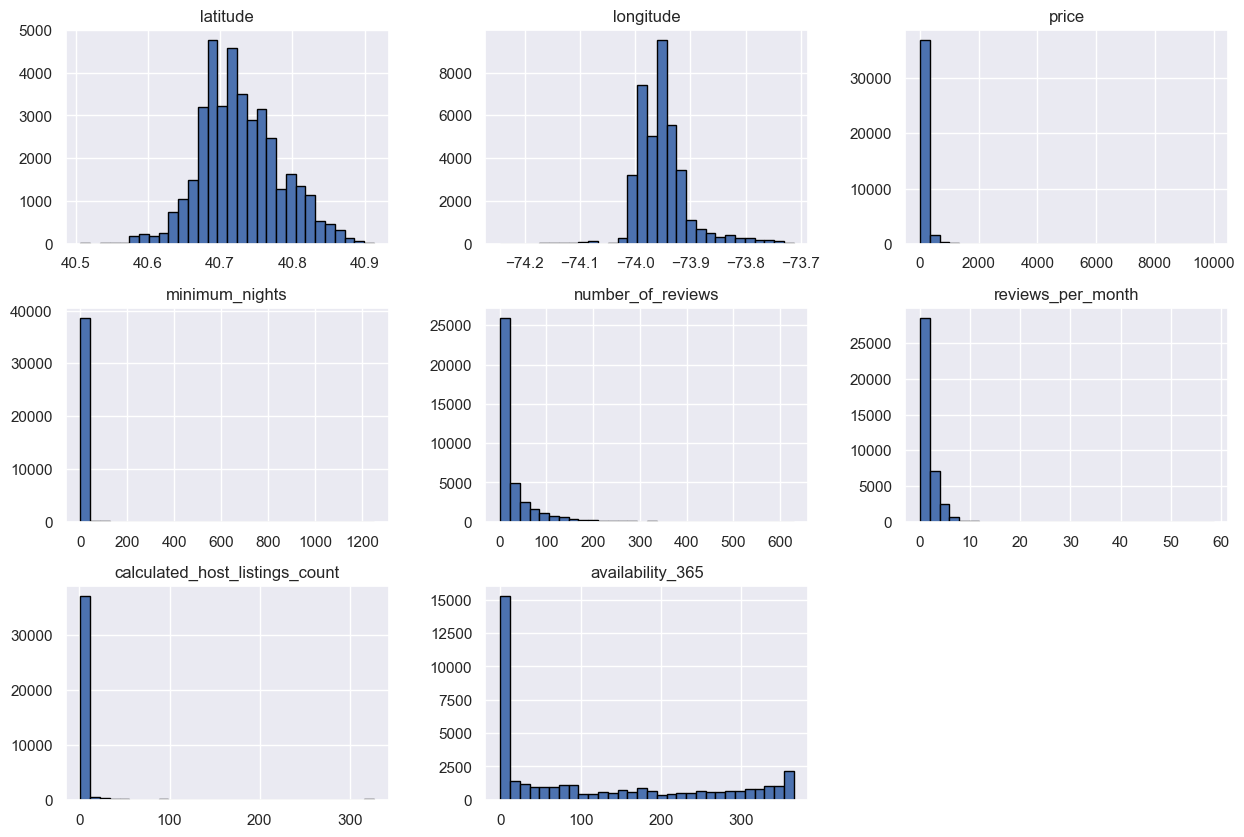

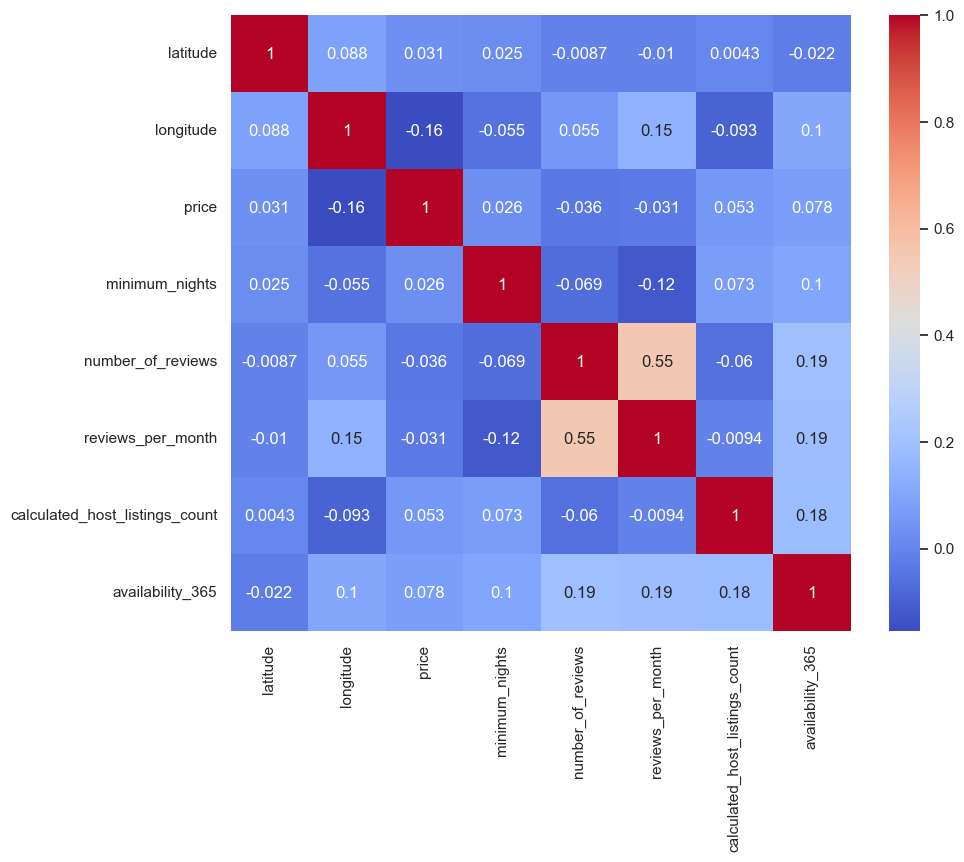

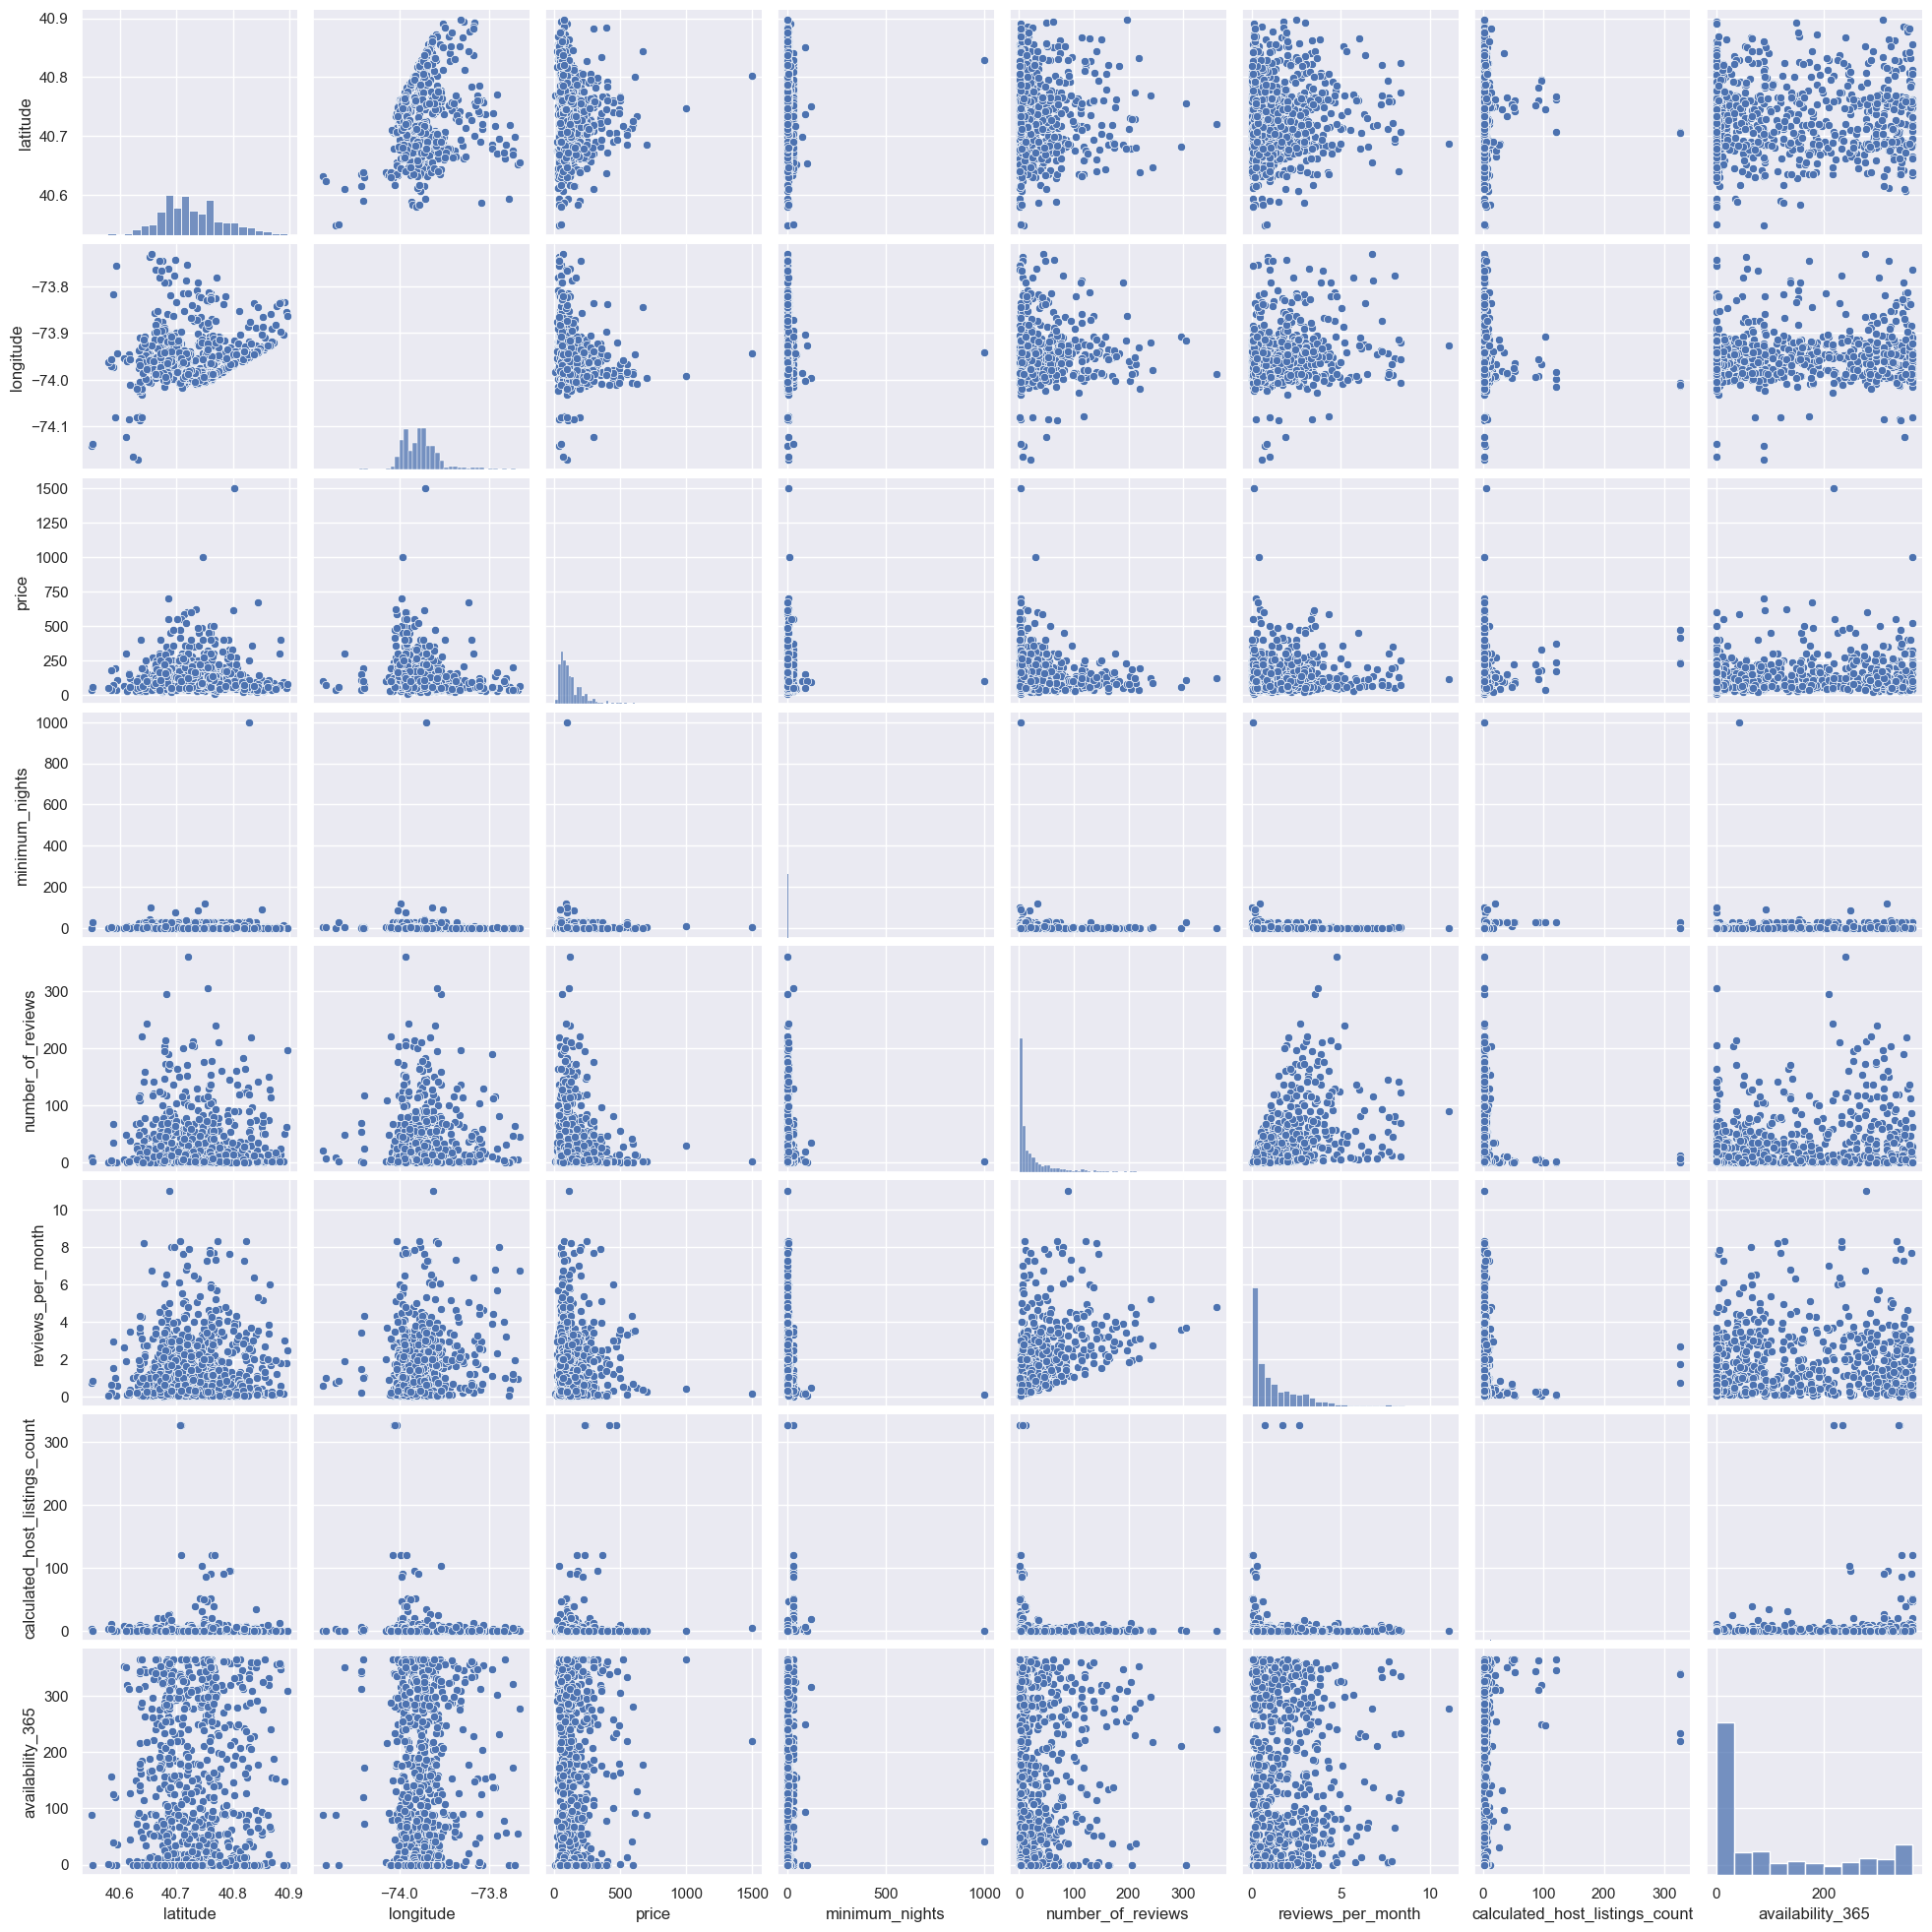

In [161]:
# 1. Распределения
data.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.show()

# 2. Корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.show()

# 3. Pair plots 
if len(data) < 2000:
    sns.pairplot(data.select_dtypes(include=[np.number]))
    plt.show()
else:
    sns.pairplot(data.select_dtypes(include=[np.number]).sample(1000))
    plt.show()

Количество объявлений по интервалам широты:
lat_group
(40.506, 40.547]       16
(40.547, 40.588]      210
(40.588, 40.628]      669
(40.628, 40.669]     3273
(40.669, 40.71]     11188
(40.71, 40.75]      10972
(40.75, 40.791]      6884
(40.791, 40.832]     4111
(40.832, 40.872]     1315
(40.872, 40.913]      205
Name: count, dtype: int64


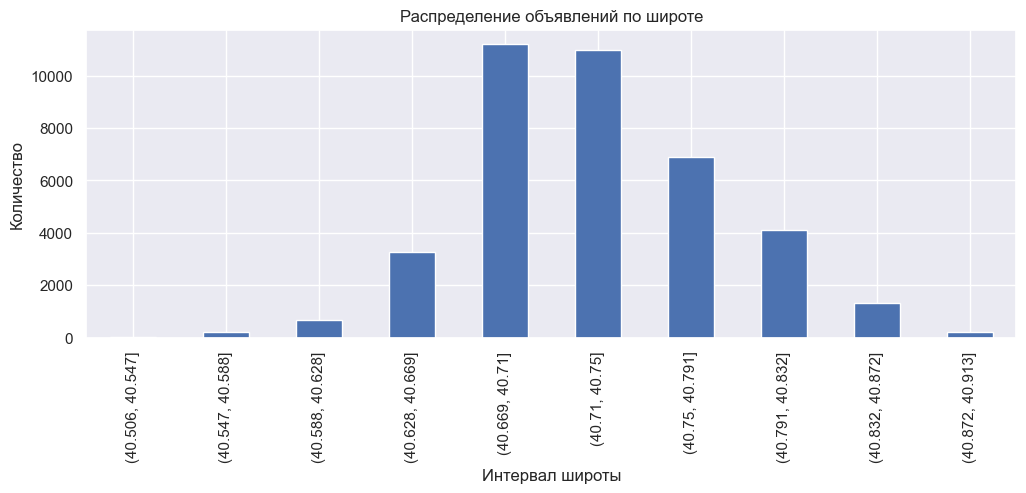

In [162]:
# latitude (широта) 
# Распределение относительно равномерное с небольшими пиками (популярные места в центре)

# Разбиваем широту на 10 интервалов
data['lat_group'] = pd.cut(data['latitude'], bins=10)

# Смотрим количество в каждом интервале
lat_counts = data['lat_group'].value_counts().sort_index()
print("Количество объявлений по интервалам широты:")
print(lat_counts)

lat_counts.plot(kind='bar', figsize=(12, 4))
plt.title('Распределение объявлений по широте')
plt.xlabel('Интервал широты')
plt.ylabel('Количество')
plt.show()


# longitude (долгота)
# Несколько явных пиков. Объявления сконцентрированы в определенных долготах (центр города). Можно использовать для определения популярных районов

In [163]:
# price (цена)
# Огромный пик в начале, затем резкое падение 
# Большинство объявлений имеют низкую цену, есть выбросы с очень высокой ценой
# Нужно обработать выбросы (цены > 500-1000)

data_before = data.copy()

data = data[(data['price'] > 20) & (data['price'] < 800)]

print(f"Было: {len(data_before)} записей")
print(f"Стало: {len(data)} записей")
print(f"Удалено: {len(data_before) - len(data)} выбросов")
print(f"\nНовая статистика цены:\n{data['price'].describe()}")

Было: 38843 записей
Стало: 38532 записей
Удалено: 311 выбросов

Новая статистика цены:
count    38532.000000
mean       133.180629
std         97.912040
min         21.000000
25%         69.000000
50%        100.000000
75%        168.250000
max        799.000000
Name: price, dtype: float64


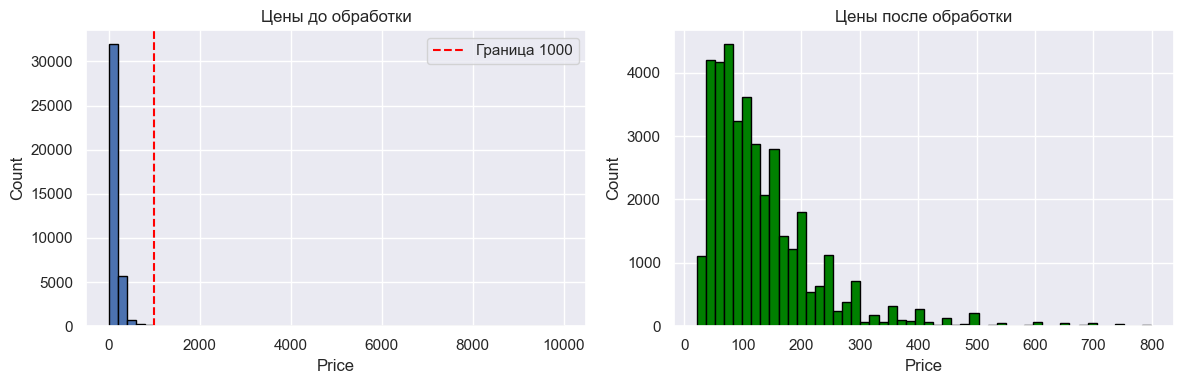

In [164]:
# Смотрим распределение до обработки
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(data_before['price'], bins=50, edgecolor='black')
plt.title('Цены до обработки')
plt.xlabel('Price')
plt.ylabel('Count')
plt.axvline(x=1000, color='red', linestyle='--', label='Граница 1000')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(data['price'], bins=50, edgecolor='black', color='green')
plt.title('Цены после обработки')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [165]:
# Большинство объявлений до $150
# Цены > $800 - это единичные случаи


Text(0.5, 1.0, 'Исходное распределение price')

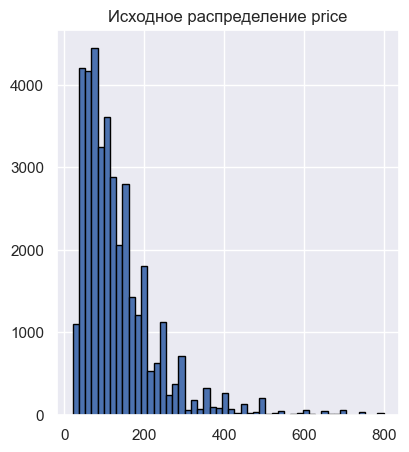

In [166]:
# Анализ распределения цены
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(data['price'], bins=50, edgecolor='black')
plt.title('Исходное распределение price')

Text(0.5, 1.0, 'Логарифмическое преобразование')

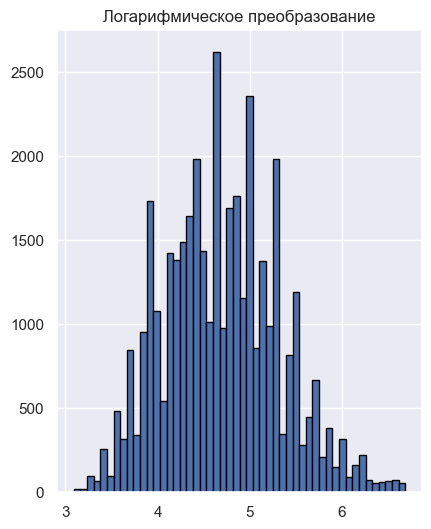

In [167]:
plt.subplot(1, 3, 2)
plt.hist(np.log1p(data['price']), bins=50, edgecolor='black')
plt.title('Логарифмическое преобразование')

In [168]:
print(data['minimum_nights'].value_counts().sort_index())

minimum_nights
1        9793
2       10248
3        6789
4        2731
5        2408
        ...  
365        18
370         1
500         2
999         2
1250        1
Name: count, Length: 88, dtype: int64


In [169]:
# minimum_nights - огромный пик в начале, затем резкое падение - большинство объявлений сдают на короткий срок
data = data[data['minimum_nights'] <= 90]  # убираем долгосрочную аренду

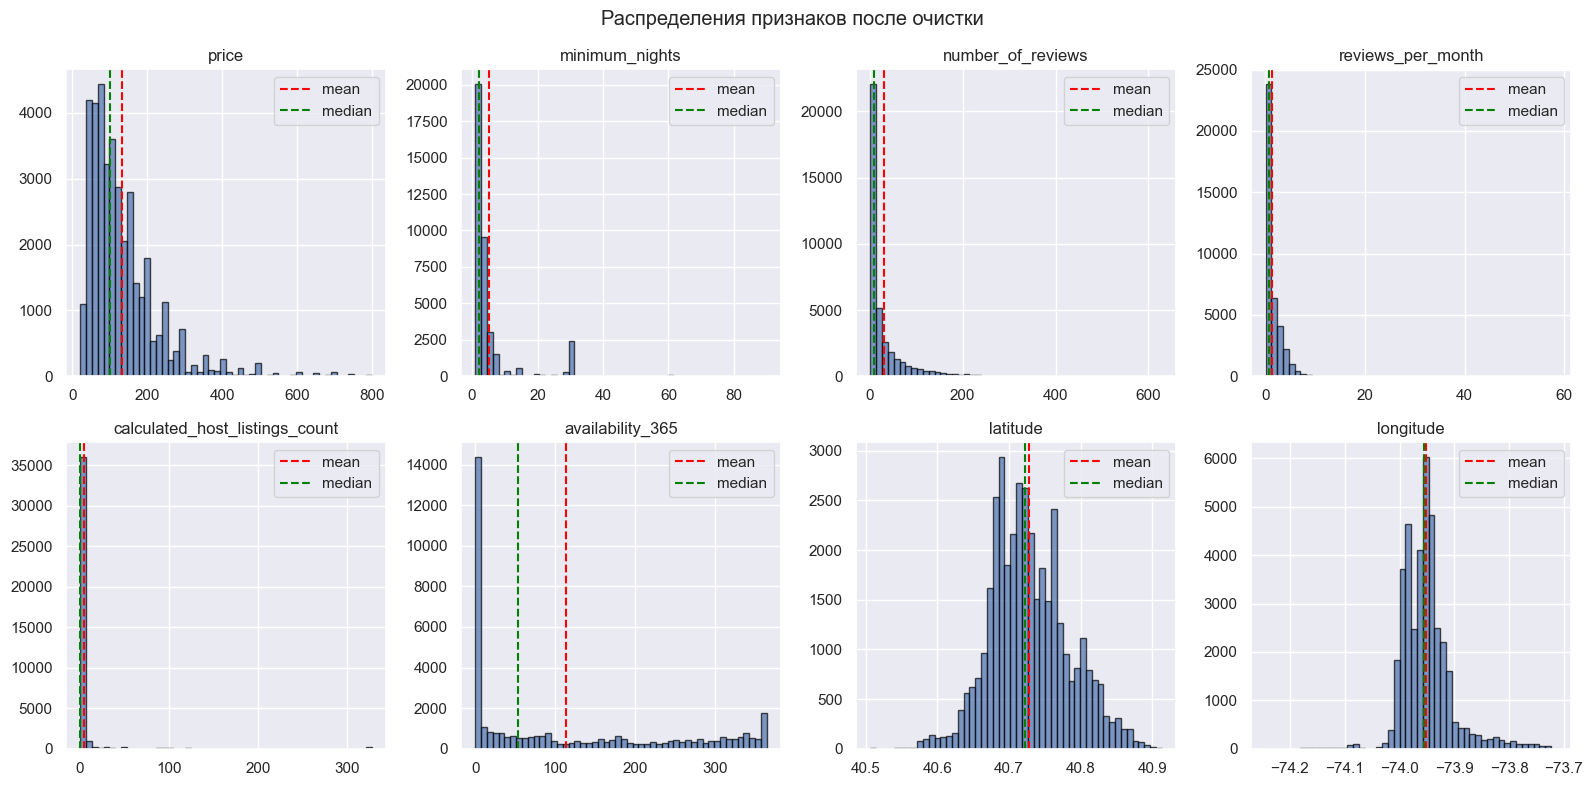

In [170]:
# Очищенные данные
data_clean = data.copy()

# Графики после очистки
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

features = ['price', 'minimum_nights', 'number_of_reviews', 
            'reviews_per_month', 'calculated_host_listings_count', 
            'availability_365', 'latitude', 'longitude']

for i, feat in enumerate(features):
    if feat in data_clean.columns:
        axes[i].hist(data_clean[feat], bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(feat)
        axes[i].axvline(data_clean[feat].mean(), color='red', linestyle='--', label='mean')
        axes[i].axvline(data_clean[feat].median(), color='green', linestyle='--', label='median')
        axes[i].legend()

plt.suptitle('Распределения признаков после очистки')
plt.tight_layout()
plt.show()

In [171]:
# Удаляем выбросы в цене
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['price'] > lower_bound) & (data['price'] < upper_bound)]

In [172]:
# Создание новых географических признаков - вычисление расстояния до центра (центр - Манхэттен)
manhattan_center = (40.7831, -73.9712)

def haversine_distance(lat, lon, center_lat, center_lon):
    R = 6371  # Радиус Земли в км
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat, lon, center_lat, center_lon])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

data['distance_to_manhattan'] = haversine_distance(
    data['latitude'], data['longitude'], 
    manhattan_center[0], manhattan_center[1]
)

In [173]:
# Кодирование редких категорий - объединяем все редкие районы в "Другие"
for col in ['neighbourhood', 'neighbourhood_group']:
    freq = data[col].value_counts()
    rare_categories = freq[freq < 50].index
    data[col + '_grouped'] = data[col].apply(
        lambda x: 'Other' if x in rare_categories else x
    )

In [180]:
data['log_price'] = np.log1p(data['price'])

In [181]:
# Выбираем финальный набор признаков
feature_cols = [
    # Исходные числовые
    'latitude', 'longitude', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
    
    # Созданные ранее признаки
    'distance_to_manhattan', 'geo_cluster',
    'log_number_of_reviews', 'log_reviews_per_month',
    'availability_ratio', 'is_popular',
    'log_minimum_nights',
    
    # Категориальные (обработанные)
    'neighbourhood_group_grouped', 'room_type', 'host_category'
]

# Создаем X (признаки) и y (целевая переменная)
X = data[available_cols].copy()
y = data['log_price'].copy()  

print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(X.head())


Размер X: (36574, 10)
Размер y: (36574,)
   latitude  longitude  minimum_nights  availability_365  number_of_reviews  \
0  40.64749  -73.97237               1               365                  9   
1  40.75362  -73.98377               1               355                 45   
3  40.68514  -73.95976               1               194                270   
4  40.79851  -73.94399              10                 0                  9   
5  40.74767  -73.97500               3               129                 74   

   reviews_per_month  calculated_host_listings_count  distance_to_manhattan  \
0               0.21                               6              15.079466   
1               0.38                               2               3.444711   
3               4.64                               1              10.935220   
4               0.10                               1               2.860664   
5               0.59                               1               3.952613   

  neighb

In [182]:
# СОЗДАЕМ НЕДОСТАЮЩИЕ ПРИЗНАКИ

# 1. Логарифмические преобразования
data['log_number_of_reviews'] = np.log1p(data['number_of_reviews'])
data['log_reviews_per_month'] = np.log1p(data['reviews_per_month'].fillna(0))
data['log_minimum_nights'] = np.log1p(data['minimum_nights'])

# 2. Коэффициенты и отношения
data['availability_ratio'] = data['availability_365'] / 365
data['is_popular'] = (data['number_of_reviews'] > data['number_of_reviews'].median()).astype(int)

# 3. Категория хозяина
def host_category(count):
    if count == 1:
        return 'single'
    elif count <= 3:
        return 'small'
    elif count <= 10:
        return 'medium'
    else:
        return 'large'

data['host_category'] = data['calculated_host_listings_count'].apply(host_category)

# 4. Географические кластеры
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
data['geo_cluster'] = kmeans.fit_predict(data[['latitude', 'longitude']])


In [183]:
# Новый, расширенный список признаков
enhanced_features = [
    # Исходные
    'latitude', 'longitude', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
    
    # Созданные
    'distance_to_manhattan', 'geo_cluster',
    'log_number_of_reviews', 'log_reviews_per_month',
    'availability_ratio', 'is_popular',
    'log_minimum_nights',
    
    # Категориальные
    'neighbourhood_group_grouped', 'room_type', 'host_category'
]

In [184]:
# Создаем обновленные X и y
X = data[available_enhanced].copy()
y = data['log_price'].copy()

print(f" X: {X.shape}")
print(f" y: {y.shape}")

 X: (36574, 17)
 y: (36574,)


In [185]:
# Определяем категориальные признаки
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {cat_cols}")

# One-hot encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"Новые признаки:")
print(X_encoded.columns[:10].tolist())

Категориальные признаки: ['neighbourhood_group_grouped', 'room_type', 'host_category']
Новые признаки:
['latitude', 'longitude', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'distance_to_manhattan', 'geo_cluster', 'log_number_of_reviews']


In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

print(f"\n=== РАЗДЕЛЕНИЕ ДАННЫХ на train/test ===")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


=== РАЗДЕЛЕНИЕ ДАННЫХ на train/test ===
X_train: (25601, 23)
X_test: (10973, 23)
y_train: (25601,)
y_test: (10973,)


In [188]:
# Создаем копии для масштабирования
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Определяем числовые признаки
numeric_cols = [
    'latitude', 'longitude', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
    'distance_to_manhattan', 'geo_cluster',
    'log_number_of_reviews', 'log_reviews_per_month',
    'availability_ratio', 'is_popular', 'log_minimum_nights'
]

# Пробуем разные scaler'ы
scaler_standard = StandardScaler()
X_train_standard = X_train.copy()
X_test_standard = X_test.copy()
X_train_standard[numeric_cols] = scaler_standard.fit_transform(X_train[numeric_cols])
X_test_standard[numeric_cols] = scaler_standard.transform(X_test[numeric_cols])

scaler_robust = RobustScaler()
X_train_robust = X_train.copy()
X_test_robust = X_test.copy()
X_train_robust[numeric_cols] = scaler_robust.fit_transform(X_train[numeric_cols])
X_test_robust[numeric_cols] = scaler_robust.transform(X_test[numeric_cols])

scaler_minmax = MinMaxScaler()
X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()
X_train_minmax[numeric_cols] = scaler_minmax.fit_transform(X_train[numeric_cols])
X_test_minmax[numeric_cols] = scaler_minmax.transform(X_test[numeric_cols])


scaled_data = {
    'StandardScaler': (X_train_standard, X_test_standard),
    'RobustScaler': (X_train_robust, X_test_robust),
    'MinMaxScaler': (X_train_minmax, X_test_minmax),
    'Без масштабирования': (X_train, X_test)
}

results = []

for name, (X_tr, X_te) in scaled_data.items():
    # Обучаем линейную регрессию
    lr = LinearRegression()
    lr.fit(X_tr, y_train)
    y_pred = lr.predict(X_te)
    
    # Считаем метрики
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    
    results.append({
        'Метод': name,
        'R2': r2,
        'MAE ($)': mae
    })
    
    print(f"{name:20} R2={r2:.4f}  MAE=${mae:.2f}")

# Лучший результат
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(f"ЛУЧШИЙ МЕТОД: {results_df.iloc[0]['Метод']}")
print(f"   R2 = {results_df.iloc[0]['R2']:.4f}")
print(f"   MAE = ${results_df.iloc[0]['MAE ($)']:.2f}")

StandardScaler       R2=0.5833  MAE=$31.83
RobustScaler         R2=0.5833  MAE=$31.83
MinMaxScaler         R2=0.5833  MAE=$31.83
Без масштабирования  R2=0.5833  MAE=$31.83
ЛУЧШИЙ МЕТОД: StandardScaler
   R2 = 0.5833
   MAE = $31.83


In [189]:
print("LINEAR REGRESSION")

# Создаем и обучаем
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Предсказываем
y_pred_lr = lr.predict(X_test_scaled)

# Считаем метрики
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lr))

print(f"R2 = {r2_lr:.4f}")
print(f"MAE = ${mae_lr:.2f}")

LINEAR REGRESSION
R2 = 0.5833
MAE = $31.83


In [190]:
print("RANDOM FOREST")

# Создаем и обучаем
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Предсказываем
y_pred_rf = rf.predict(X_test)

# Считаем метрики
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf))

print(f"R2 = {r2_rf:.4f}")
print(f"MAE = ${mae_rf:.2f}")

RANDOM FOREST
R2 = 0.6515
MAE = $29.17


In [138]:
print("GRADIENT BOOSTING")

# Создаем и обучаем
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# Предсказываем
y_pred_gb = gb.predict(X_test)

# Считаем метрики
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_gb))

print(f"R2 = {r2_gb:.4f}")
print(f"MAE = ${mae_gb:.2f}")

GRADIENT BOOSTING
R2 = 0.6344
MAE = $28.38


In [140]:
# Создаем таблицу с результатами
results = pd.DataFrame({
    'Модель': ['Linear', 'Random Forest', 'Gradient Boosting'],
    'R2': [r2_lr, r2_rf, r2_gb],
    'MAE ($)': [mae_lr, mae_rf, mae_gb]
})

# Сортируем по R2 (от лучшей к худшей)
results = results.sort_values('R2', ascending=False).round(4)
print(results.to_string(index=False))

# Находим лучшую
best_idx = results['R2'].idxmax()
best_model = results.iloc[best_idx]
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model['Модель']}")
print(f"   R2 = {best_model['R2']:.4f}")
print(f"   MAE = ${best_model['MAE ($)']:.2f}")

           Модель     R2  MAE ($)
    Random Forest 0.6417  27.7772
Gradient Boosting 0.6344  28.3837
           Linear 0.5761  30.2632
ЛУЧШАЯ МОДЕЛЬ: Gradient Boosting
   R2 = 0.6344
   MAE = $28.38


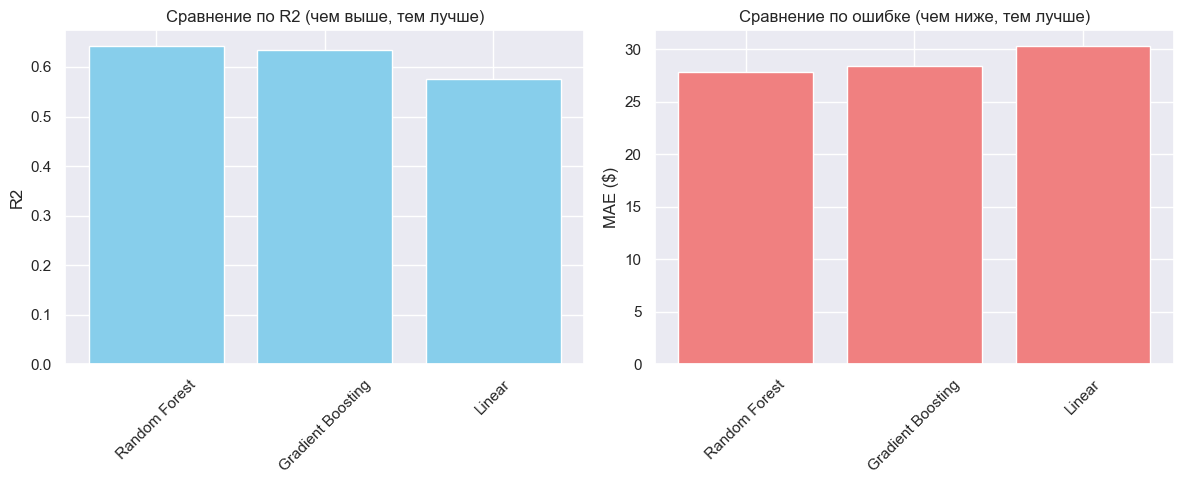

In [141]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График R2
ax1.bar(results['Модель'], results['R2'], color='skyblue')
ax1.set_title('Сравнение по R2 (чем выше, тем лучше)')
ax1.set_ylabel('R2')
ax1.tick_params(axis='x', rotation=45)

# График MAE
ax2.bar(results['Модель'], results['MAE ($)'], color='lightcoral')
ax2.set_title('Сравнение по ошибке (чем ниже, тем лучше)')
ax2.set_ylabel('MAE ($)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()